##**Weather Classification Using ResNet50 Transfer Learning**






### 1. Import Libraries


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile

### 2. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 3. Extract Dataset

In [ ]:
zip_path = "/content/drive/MyDrive/archive.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/weather_dataset")

print("Done Extracting")

Done Extracting


### 4. Dataset Verification

In [ ]:
print(os.listdir("/content/weather_dataset"))

dataset_path = "/content/weather_dataset/Multi-class Weather Dataset"
print(os.listdir(dataset_path))

['Multi-class Weather Dataset']
['Sunrise', 'Rain', 'Shine', 'Cloudy']


### 5. Data Preprocessing and Augmentation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 224
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

### 6. Load Training and Validation Data

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

In [ ]:
train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

print(train_data.class_indices)

Found 901 images belonging to 4 classes.
Found 224 images belonging to 4 classes.
{'Cloudy': 0, 'Rain': 1, 'Shine': 2, 'Sunrise': 3}


### 7. Build ResNet50 Model

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential

In [ ]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

### 8. Create Final Classification Model

In [ ]:
from tensorflow.keras.layers import Dropout

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_data.num_classes, activation='softmax')
])

### 9. Compile Model

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### 10. Define Callbacks

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    save_best_only=True
)

### 11. Train the Model (Initial Training-Feature Extraction Phase)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 38s 903ms/step - accuracy: 0.4928 - loss: 1.2421 - val_accuracy: 0.7768 - val_loss: 0.6305
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 592ms/step - accuracy: 0.7680 - loss: 0.5997 - val_accuracy: 0.8750 - val_loss: 0.4140
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 611ms/step - accuracy: 0.8912 - loss: 0.3449 - val_accuracy: 0.8929 - val_loss: 0.3182
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 589ms/step - accuracy: 0.9112 - loss: 0.2857 - val_accuracy: 0.9062 - val_loss: 0.2671
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 632ms/step - accuracy: 0.9201 - loss: 0.2370 - val_accuracy: 0.9062 - val_loss: 0.2407
Epoch 6/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 590ms/step - accuracy: 0.9567 - loss: 0.1659 - val_accuracy: 0.9018 - val_loss: 0.2319
Epoch 7/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 587ms/step - accuracy: 0.9512 - loss: 0.1513 - val_accuracy: 0.8929 - val_loss: 0.2244
Epoch 8/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 588ms/step - accuracy: 0.9656 - loss: 0.1210 - val_accu

###12. Fine-Tune ResNet50 Model

In [ ]:
base_model.trainable = True

# freeze early layers, train last 50 layers only
for layer in base_model.layers[:-50]:
    layer.trainable = False

### 13. Re-compile Model for Fine-Tuning

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### 14. Fine-Tuning Training

In [ ]:
history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,   # extra training
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.8568 - loss: 0.3918 - val_accuracy: 0.9375 - val_loss: 0.1430
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 19s 648ms/step - accuracy: 0.9323 - loss: 0.2295 - val_accuracy: 0.9420 - val_loss: 0.1215
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 624ms/step - accuracy: 0.9478 - loss: 0.1559 - val_accuracy: 0.9464 - val_loss: 0.1133
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 612ms/step - accuracy: 0.9700 - loss: 0.1042 - val_accuracy: 0.9509 - val_loss: 0.1103
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 563ms/step - accuracy: 0.9811 - loss: 0.0805 - val_accuracy: 0.9420 - val_loss: 0.1132
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 570ms/step - accuracy: 0.9867 - loss: 0.0574 - val_accuracy: 0.9375 - val_loss: 0.1173
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 597ms/step - accuracy: 0.9767 - loss: 0.0790 - val_accuracy: 0.9330 - val_loss: 0.1198


### 15. Model Evaluation

In [ ]:
loss, accuracy = model.evaluate(val_data)

print("Validation Accuracy:", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 233ms/step - accuracy: 0.9509 - loss: 0.1103
Validation Accuracy: 0.9508928656578064


### 16. Accuracy Visualization

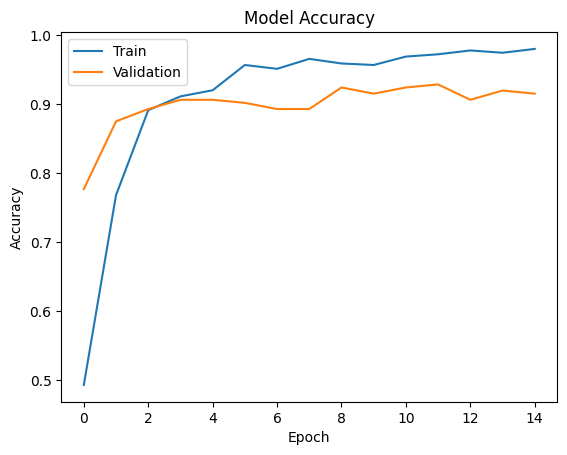

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.show()

### 17. Save Trained Model

In [ ]:
model.save("weather_resnet50.keras")

### 18. Test Weather Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Predicted Weather: Shine


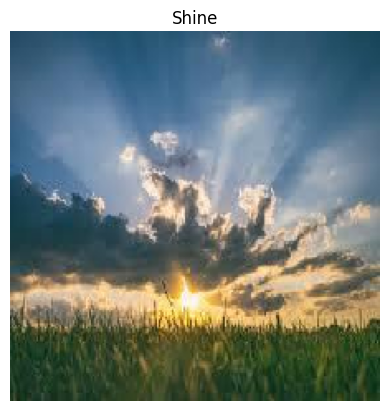

In [ ]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input

img_array = preprocess_input(img_array)

# upload image first
img_path = "/content/images.jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

prediction = model.predict(img_array)

class_names = list(train_data.class_indices.keys())

print("Predicted Weather:", class_names[np.argmax(prediction)])

plt.imshow(img)
plt.title(class_names[np.argmax(prediction)])
plt.axis('off')
plt.show()